In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.cvtColor(cv2.imread("D:\Computer-Vision\Image-Processing\Edges\edge\house.jpg"),cv2.COLOR_BGR2RGB)

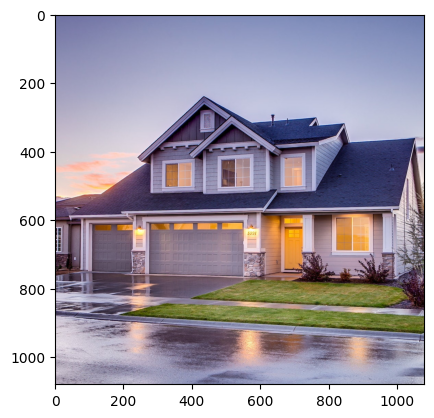

In [4]:
plt.imshow(img)
plt.show()

In [5]:
custom_edge_detection_x = np.array([[0,  0,  0],
                                    [-1, 0, +1],
                                    [0,  0,  0]])

custom_edge_detection_y = np.array([[0, -1,  0], 
                                    [0,  0,  0],
                                    [0, +1,  0]])

In [6]:
img_edge_x = cv2.filter2D(img,-1,custom_edge_detection_x)

Can not detect the leftside edges bacause of that uint8 can not support the negative values. (When use the filters like X its going to calculate the next pixel value with the perivious one like this >>> (-1 * I0) + (0*I1) + (+1 * I2) and if I2 < I0 then answer is negative)

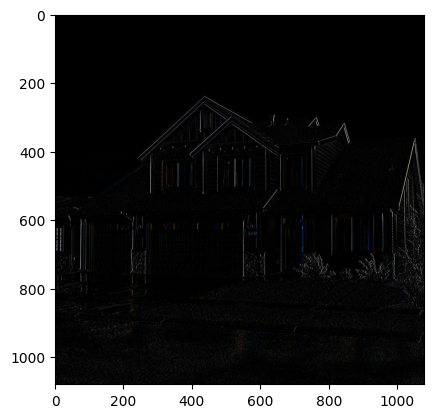

In [8]:
plt.imshow(img_edge_x)
plt.show()

Change DataType to float 64bit For supporting the negative values that uint 8bit can not support

Then converting negative values to positive with cv2.convertScaleAbs and solving the negative points also the format 64F to uint8.

In [11]:
img_edge_x = cv2.filter2D(img,cv2.CV_64F,custom_edge_detection_x)
img_edge_x = cv2.convertScaleAbs(img_edge_x)

In [12]:
img_edge_x.max()

np.uint8(255)

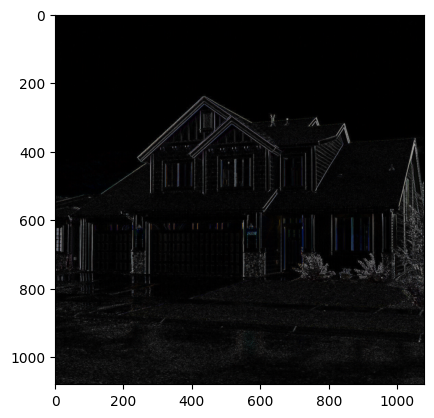

In [13]:
plt.imshow(img_edge_x)
plt.show()

Edge: Y

In [15]:
img_edge_y = cv2.filter2D(img,cv2.CV_64F,custom_edge_detection_y)
img_edge_y = cv2.convertScaleAbs(img_edge_y)

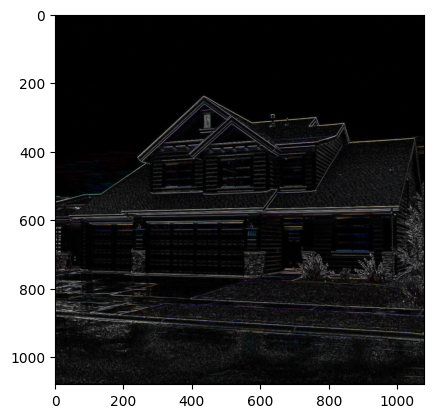

In [16]:
plt.imshow(img_edge_y)
plt.show()

Edge : xy

Using 2 edges to gether with cv2.add method.

In [19]:
img_edge_xy = cv2.add(img_edge_y,img_edge_x)

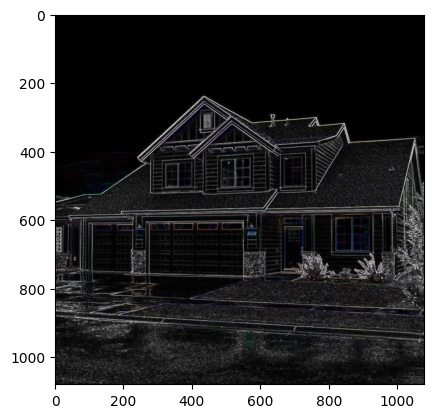

In [20]:
plt.imshow(img_edge_xy)
plt.show()

Edge detection function.

In [21]:
def custom_edge_detection(img,threshold=False,thmin=50,thmax=255,gaussianBlur=False):
    custom_edge_detection_x = np.array([[0,  0,  0],
                                        [-1, 0, +1],
                                        [0,  0,  0]])

    custom_edge_detection_y = np.array([[0, -1,  0], 
                                        [0,  0,  0],
                                        [0, +1,  0]])

    if gaussianBlur == True:
        img = cv2.GaussianBlur(img,(3,3),0)
    
    img_edge_x = cv2.filter2D(img,cv2.CV_64F,custom_edge_detection_x)
    img_edge_x = cv2.convertScaleAbs(img_edge_x)

    img_edge_y = cv2.filter2D(img,cv2.CV_64F,custom_edge_detection_y)
    img_edge_y = cv2.convertScaleAbs(img_edge_y)

    img_edge_xy = cv2.add(img_edge_y,img_edge_x)
     
    if threshold == True: 
        _ , img_edge_xy = cv2.threshold(img_edge_xy,thmin,thmax,cv2.THRESH_BINARY)
    
    return img_edge_xy

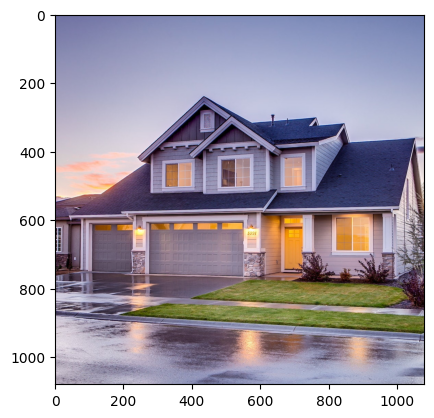

In [22]:
plt.imshow(img)
plt.show()

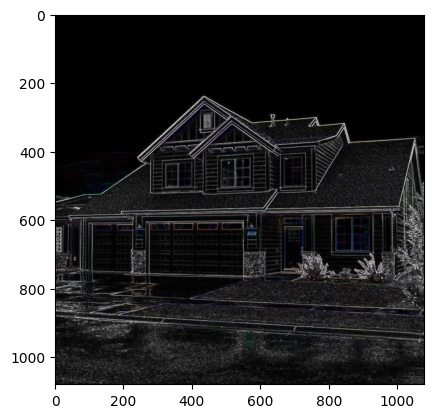

In [23]:
plt.imshow(custom_edge_detection(img))
plt.show()

Detecting some points that are not realy edges and we are going to solve this problem.

Gradien Threshold. lower treshold 50 and upper treshold 255.

TRESH_BINARY >>> if lower than lower treshold set it to 0 and if its upper than lower trashold set it to 255.

In [32]:
_ , img_edge_xy_th = cv2.threshold(img_edge_xy,50,255,cv2.THRESH_BINARY)

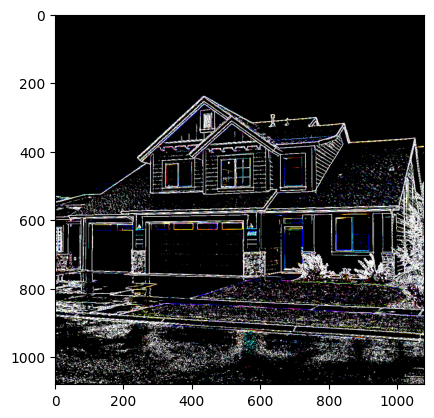

In [33]:
plt.imshow(img_edge_xy_th)
plt.show()

In [34]:
img_edge_xy_th.min()

np.uint8(0)

In [35]:
img_edge_xy_th.max()

np.uint8(255)

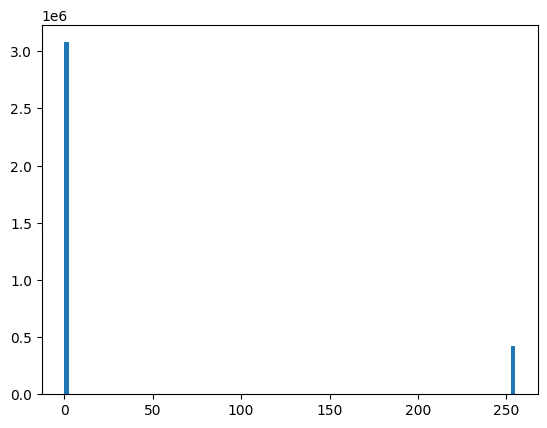

In [36]:
plt.hist(img_edge_xy_th.reshape(-1),bins=100)
plt.show()

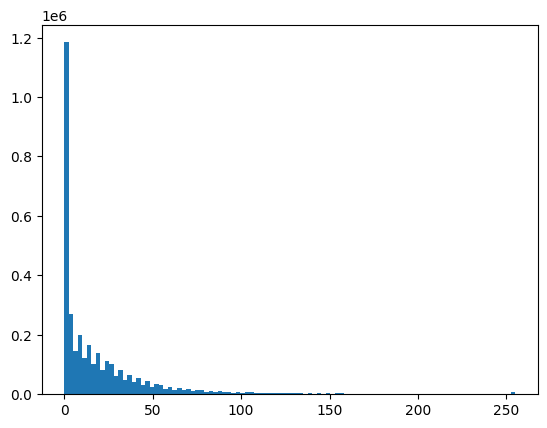

In [37]:
plt.hist(img_edge_xy.reshape(-1),bins=100)
plt.show()

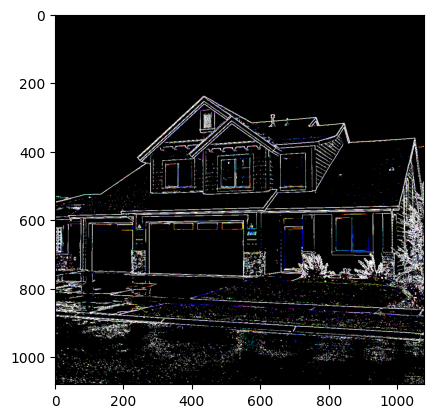

In [38]:
plt.imshow(custom_edge_detection(img,threshold=True,thmin=70))
plt.show()

Gaussian Blur.

In [39]:
img_blur = cv2.GaussianBlur(img,(3,3),0)

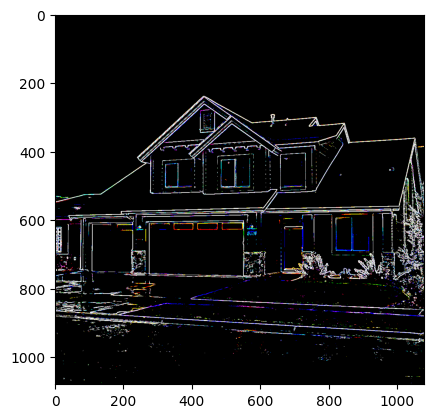

In [42]:
plt.imshow(custom_edge_detection(img_blur,threshold=True,thmin=55))
plt.show()

custom_edge_detection + guassian.

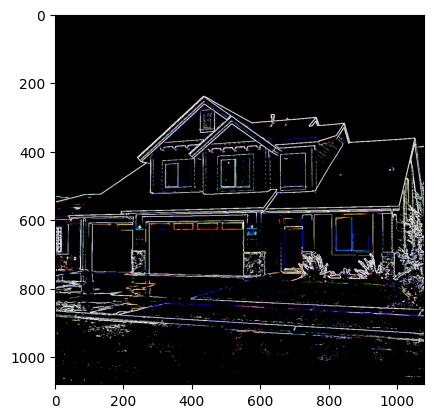

In [43]:
plt.imshow(custom_edge_detection(img,threshold=True,thmin=50,gaussianBlur=True))
plt.show()